In [2]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# define file to read 1d histogram and return counts and bin edges
def read_th1(root_file, path):
    """Read a 1D histogram (TH1) and return (counts, bin_edges).

    counts     : 1D float array, length N (bin contents, no under/overflow)
    bin_edges  : 1D float array, length N+1 (left edge of bin 0 ... right edge of bin N-1)
    """
    with uproot.open(root_file) as f:
        hist = f[path]
        counts, bin_edges = hist.to_numpy(flow=False)
    return counts, bin_edges


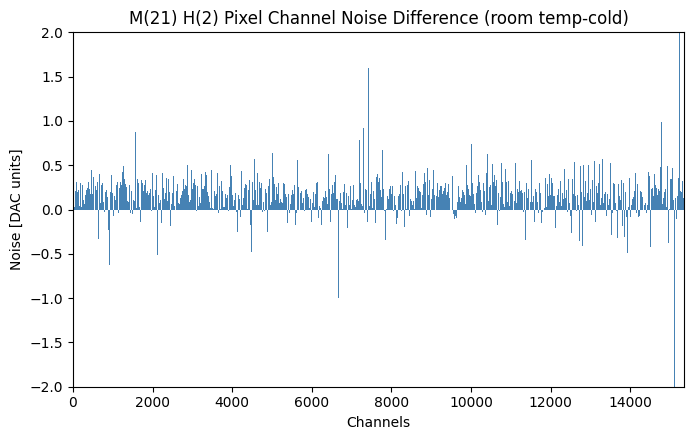

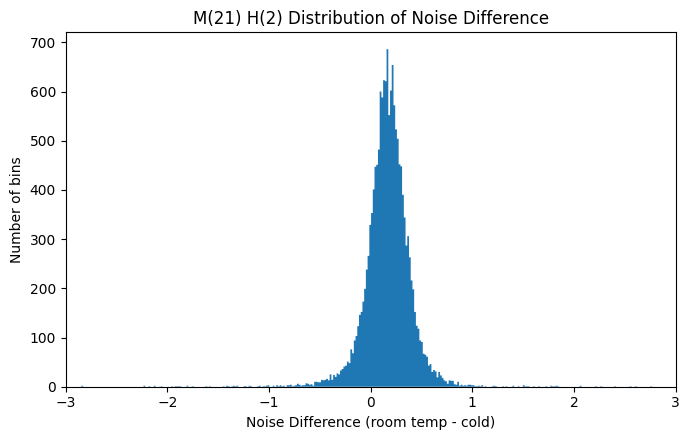

In [4]:
# defines counts and bins for mod21 hybrid2 at room temp
# countsh2r = counts hybrid 2 room temp
countsh2r, binsh2r = read_th1("PS_16_FNL-10021_2025-12-01_17h45m09s_+21C_PSquickTest_v6-22.root"
,"Detector/Board_0/OpticalGroup_1/Hybrid_2/D_B(0)_O(1)_PixelChannelNoise_Hybrid(2);1")
# defines counts and bins for mod21 hybrid2 at cold temp
# countsh2c = counts hybrid 2 cold temp
countsh2c, binsh2c = read_th1("PS_16_FNL-10021_2025-12-01_19h59m48s_-35C_PSquickTest_v6-22.root", "Detector/Board_0/OpticalGroup_1/Hybrid_2/D_B(0)_O(1)_PixelChannelNoise_Hybrid(2);1")
# defines difference in counts (hot-cold) for mod21 hybrid 2
diffh2 = countsh2r - countsh2c
# plots mod21 hybrid2 pixel noise differences fxn of noise vs pixel number
centers = 0.5 * (binsh2r[:-1] + binsh2r[1:])
widths = np.diff(binsh2r)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(centers, diffh2, width=widths, align="center",
           color="steelblue", edgecolor="none")
ax.set_xlabel("Channels")
ax.set_ylabel("Noise [DAC units]")
ax.set_title("M(21) H(2) Pixel Channel Noise Difference (room temp-cold)")
ax.margins(x=0)
fig.tight_layout()
fig.savefig("m21_ssa_noise_diff_hybrid2.png", dpi=150)
fig.savefig("m21_ssa_noise_diff_hybrid2.pdf")
ax.set_ylim(-2, 2)
# plots noise difference distribution for mod21 hybrid 2
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(
    diffh2,
    bins=2000,
    histtype="stepfilled"
)

ax.set_xlabel("Noise Difference (room temp - cold)")
ax.set_ylabel("Number of bins")
ax.set_title("M(21) H(2) Distribution of Noise Difference")
ax.set_xlim(-3, 3)

plt.tight_layout()
plt.show()

fig.savefig("m21_ssa_noise_diff_h2_distribution.png", dpi=150)
fig.savefig("m21_ssa_noise_diff_h2_distribution.pdf")

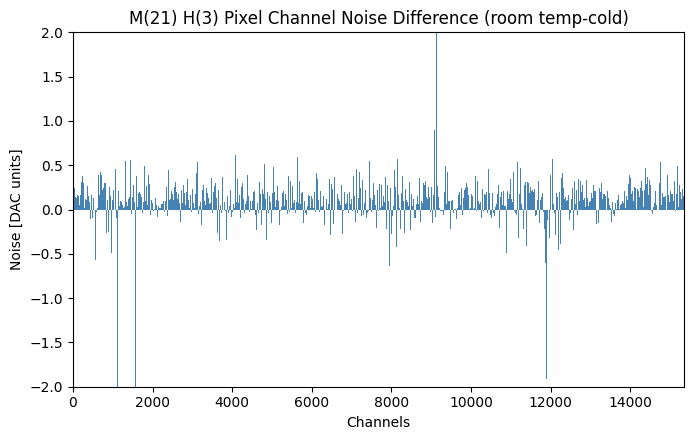

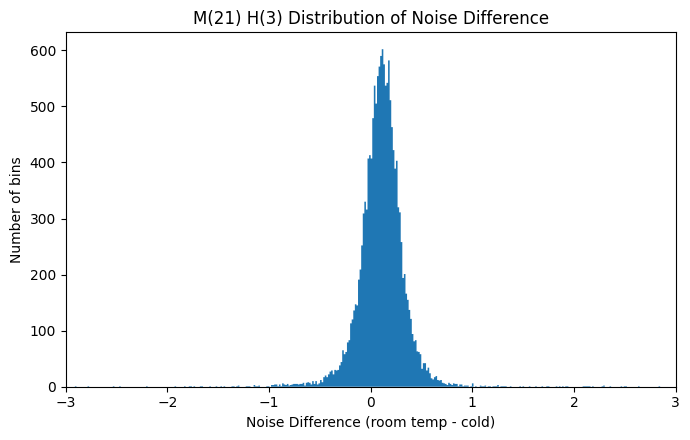

In [5]:
# defines counts and bins for mod21 hybrid 3 room temp
countsh3r, binsh3r = read_th1("PS_16_FNL-10021_2025-12-01_17h45m09s_+21C_PSquickTest_v6-22.root"
,"Detector/Board_0/OpticalGroup_1/Hybrid_3/D_B(0)_O(1)_PixelChannelNoise_Hybrid(3);1")
# defines counts and bins for mod21 hybrid 3 cold temp
countsh3c, binsh3c = read_th1("PS_16_FNL-10021_2025-12-01_19h59m48s_-35C_PSquickTest_v6-22.root", "Detector/Board_0/OpticalGroup_1/Hybrid_3/D_B(0)_O(1)_PixelChannelNoise_Hybrid(3);1")
# defines diff (hot-cold) in counts (noise) for mod21 hybrid 3
diffh3 = countsh3r - countsh3c
# plots fxn of noise vs pixel number for mod21 hybrid 3
centers = 0.5 * (binsh3r[:-1] + binsh3r[1:])
widths = np.diff(binsh3r)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(centers, diffh3, width=widths, align="center",
           color="steelblue", edgecolor="none")
ax.set_xlabel("Channels")
ax.set_ylabel("Noise [DAC units]")
ax.set_title("M(21) H(3) Pixel Channel Noise Difference (room temp-cold)")
ax.margins(x=0)
fig.tight_layout()
fig.savefig("m21_ssa_noise_diff_hybrid3.png", dpi=150)
fig.savefig("m21_ssa_noise_diff_hybrid3.pdf")
ax.set_ylim(-2, 2)
# plots distribution of noise for mod21 hybrid3
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(
    diffh3,
    bins=2000,
    histtype="stepfilled"
)

ax.set_xlabel("Noise Difference (room temp - cold)")
ax.set_ylabel("Number of bins")
ax.set_title("M(21) H(3) Distribution of Noise Difference")
ax.set_xlim(-3, 3)

plt.tight_layout()
plt.show()

fig.savefig("m21_ssa_noise_diff_h3_distribution.png", dpi=150)
fig.savefig("m21_ssa_noise_diff_h3_distribution.pdf")

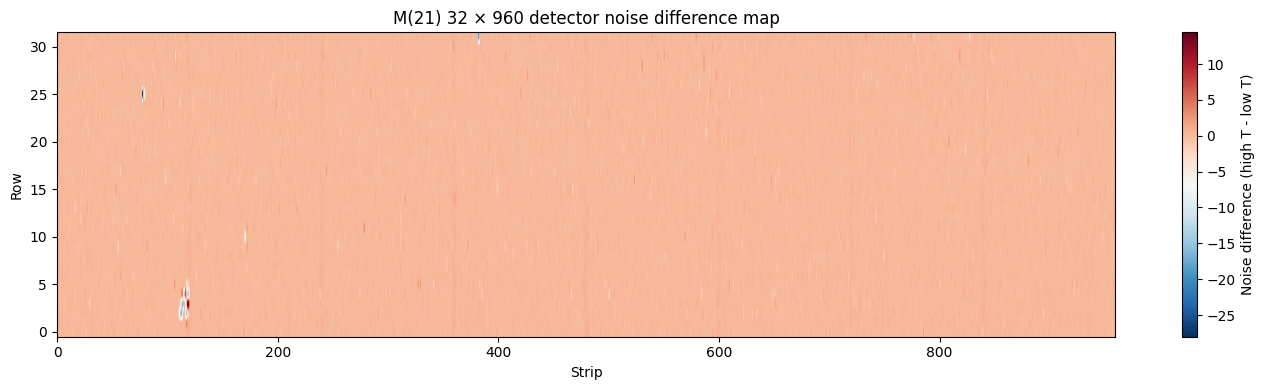

In [12]:
#defines 2d histogram reader fxn
def read_th2(root_file, path):
    """Read a 2D histogram (TH2) and return (values, x_edges, y_edges).

    values   : 2D float array of shape (n_x, n_y) indexed [x_bin, y_bin]
    x_edges  : 1D float array, length n_x + 1
    y_edges  : 1D float array, length n_y + 1
    """
    with uproot.open(root_file) as f:
        hist = f[path]
        values, x_edges, y_edges = hist.to_numpy(flow=False)
    return values, x_edges, y_edges
# creates numpy array of zeroes thats same size as data array will be
combined = np.zeros([32, 960])
# defines fxn to find diff between 2 histograms counts
def diff_th2(rootpath1, rootpath2, histpath):
    """
    Read two TH2 histograms and return hist2 - hist1.
    """

    values1, _, _ = read_th2(rootpath1, histpath)
    values2, _, _ = read_th2(rootpath2, histpath)

    return values2 - values1
# defines fxn to identify 2d histograms by their hybrid and chip number and return their full file name
def make_histpath(hybrid, chip):
    return (
        f"Detector/Board_0/OpticalGroup_1/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(1)_H({hybrid})_2DChannelNoise_Chip({chip});1"
    )
# for loop that puts mod21 hybrid 2 data in bottom of np array
for i, chip in enumerate(range(15, 7, -1)):

    histpath = make_histpath(2, chip)

    diff = diff_th2(
        "PS_16_FNL-10021_2025-12-01_19h59m48s_-35C_PSquickTest_v6-22.root",
        "PS_16_FNL-10021_2025-12-01_17h45m09s_+21C_PSquickTest_v6-22.root",
        histpath
    )

    diff = np.fliplr(diff)

    c0 = i * 120
    c1 = c0 + 120

    combined[0:16, c0:c1] = diff.T
# for loop that puts mod21 hybrid 3 data in top of np array
for i, chip in enumerate(range(8, 16)):

    histpath = make_histpath(3, chip)

    diff = diff_th2(
        "PS_16_FNL-10021_2025-12-01_19h59m48s_-35C_PSquickTest_v6-22.root",
        "PS_16_FNL-10021_2025-12-01_17h45m09s_+21C_PSquickTest_v6-22.root",
        histpath
    )

    diff = np.flipud(diff)

    c0 = i * 120
    c1 = c0 + 120

    combined[16:32, c0:c1] = diff.T
# plots 2d histogram showing full noise diff (hot-cold) for all mpa chips
fig, ax = plt.subplots(figsize=(14, 4))

im = ax.imshow(
    combined,
    origin="lower",
    aspect="auto",
    cmap="RdBu_r"
)

fig.colorbar(
    im,
    ax=ax,
    label="Noise difference (high T - low T)"
)

ax.set_xlabel("Strip")
ax.set_ylabel("Row")
ax.set_title("M(21) 32 × 960 detector noise difference map")

plt.tight_layout()
plt.savefig("m21_noise_difference_map.png", dpi=150)
plt.savefig("m21_noise_difference_map.pdf")
plt.show()


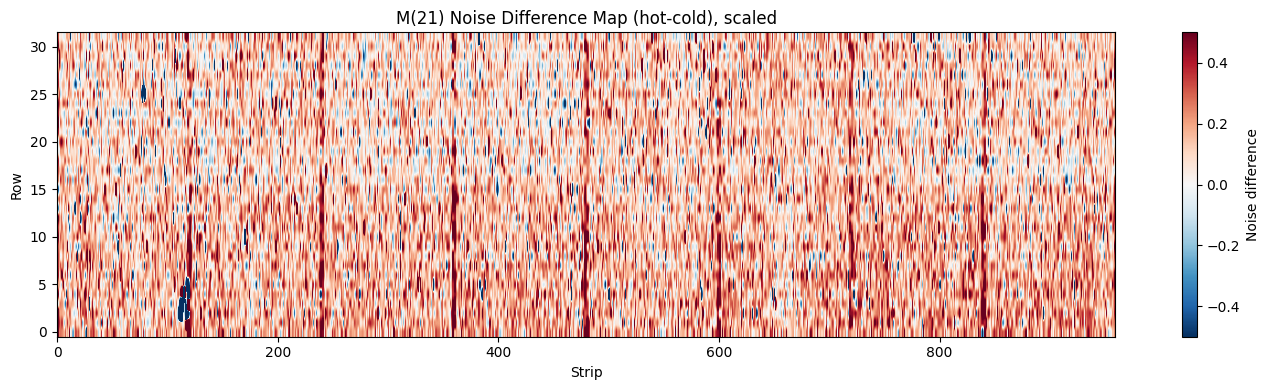

In [37]:
# changes scale
fig, ax = plt.subplots(figsize=(14, 4))

im = ax.imshow(
    combined,
    origin="lower",
    aspect="auto",
    cmap="RdBu_r",
    vmin=-0.5,
    vmax=0.5
)

fig.colorbar(im, ax=ax, label="Noise difference")
ax.set_xlabel("Strip")
ax.set_ylabel("Row")
ax.set_title("M(21) Noise Difference Map (hot-cold), scaled")

plt.tight_layout()
plt.savefig("m21_noise_difference_map_scaled.png", dpi=150)
plt.savefig("m21_noise_difference_map_scaled.pdf")
plt.show()

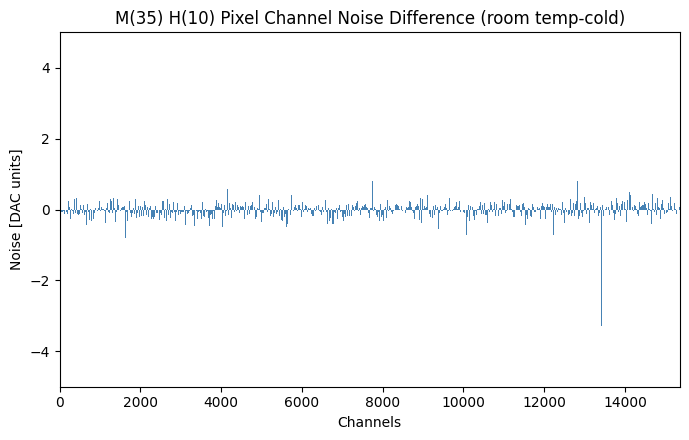

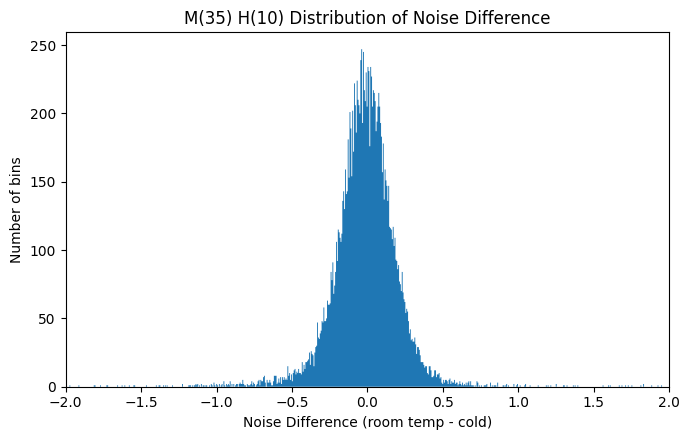

In [9]:
# defines counts and bins for mod35 hybrid10 at room temp
# countsh2r = counts hybrid 2 room temp
countsh10r, binsh10r = read_th1("PS_16_FNL-10035_2025-12-01_17h45m09s_+21C_PSquickTest_v6-22.root"
,"Detector/Board_0/OpticalGroup_5/Hybrid_10/D_B(0)_O(5)_PixelChannelNoise_Hybrid(10);1")
# defines counts and bins for mod35 hybrid10 at cold temp
# countsh2c = counts hybrid 2 cold temp
countsh10c, binsh10c = read_th1("PS_16_FNL-10035_2025-12-01_19h59m48s_-34C_PSquickTest_v6-22.root", "Detector/Board_0/OpticalGroup_5/Hybrid_10/D_B(0)_O(5)_PixelChannelNoise_Hybrid(10);1")
# defines difference in counts (hot-cold) for mod35 hybrid 10
diffh10 = countsh10r - countsh10c
# plots mod35 hybrid10 pixel noise differences fxn of noise vs pixel number
centers = 0.5 * (binsh10r[:-1] + binsh10r[1:])
widths = np.diff(binsh10r)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(centers, diffh10, width=widths, align="center",
           color="steelblue", edgecolor="none")
ax.set_xlabel("Channels")
ax.set_ylabel("Noise [DAC units]")
ax.set_title("M(35) H(10) Pixel Channel Noise Difference (room temp-cold)")
ax.margins(x=0)
fig.tight_layout()
fig.savefig("m35_ssa_noise_diff_hybrid10.png", dpi=150)
fig.savefig("m35_ssa_noise_diff_hybrid10.pdf")
ax.set_ylim(-5, 5)
# plots noise difference distribution for mod35 hybrid 10
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(
    diffh10,
    bins=1000,
    histtype="stepfilled"
)

ax.set_xlabel("Noise Difference (room temp - cold)")
ax.set_ylabel("Number of bins")
ax.set_title("M(35) H(10) Distribution of Noise Difference")
ax.set_xlim(-2, 2)

plt.tight_layout()
plt.show()

fig.savefig("m35_ssa_noise_diff_h10_distribution.png", dpi=150)
fig.savefig("m35_ssa_noise_diff_h10_distribution.pdf")


In [10]:
# defines counts and bins for mod35 hybrid 11 room temp
countsh11r, binsh11r = read_th1("PS_16_FNL-10035_2025-12-01_17h45m09s_+21C_PSquickTest_v6-22.root"
,"Detector/Board_0/OpticalGroup_5/Hybrid_11/D_B(0)_O(5)_PixelChannelNoise_Hybrid(11);1")
# defines counts and bins for mod35 hybrid 11 cold temp
countsh11c, binsh11c = read_th1("PS_16_FNL-10035_2025-12-01_19h59m48s_-34C_PSquickTest_v6-22.root", "Detector/Board_0/OpticalGroup_5/Hybrid_11/D_B(0)_O(5)_PixelChannelNoise_Hybrid(11);1")
# defines diff (hot-cold) in counts (noise) for mod21 hybrid 3
diffh11 = countsh11r - countsh11c

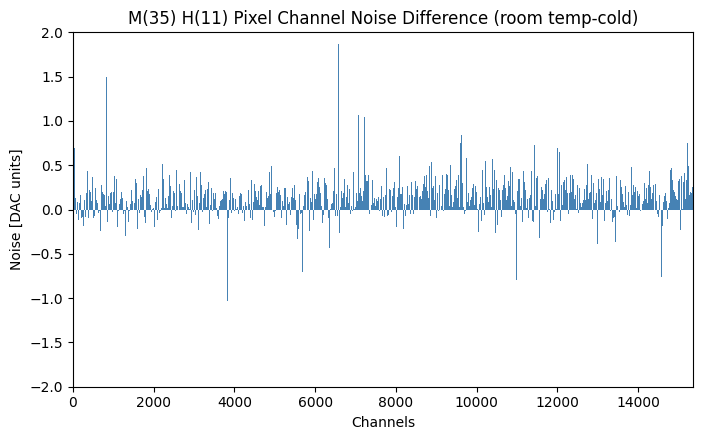

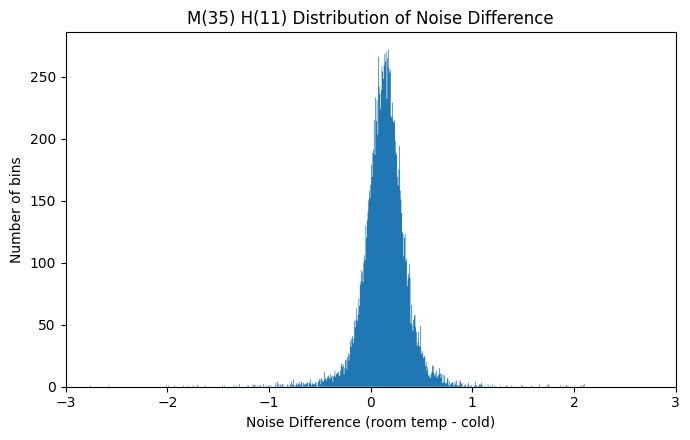

In [11]:
# plots fxn of noise vs pixel number for mod21 hybrid 3
centers = 0.5 * (binsh11r[:-1] + binsh11r[1:])
widths = np.diff(binsh11r)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(centers, diffh11, width=widths, align="center",
           color="steelblue", edgecolor="none")
ax.set_xlabel("Channels")
ax.set_ylabel("Noise [DAC units]")
ax.set_title("M(35) H(11) Pixel Channel Noise Difference (room temp-cold)")
ax.margins(x=0)
fig.tight_layout()
fig.savefig("m35_ssa_noise_diff_hybrid11.png", dpi=150)
fig.savefig("m35_ssa_noise_diff_hybrid11.pdf")
ax.set_ylim(-2, 2)
# plots distribution of noise for mod21 hybrid3
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(
    diffh11,
    bins=1000,
    histtype="stepfilled"
)

ax.set_xlabel("Noise Difference (room temp - cold)")
ax.set_ylabel("Number of bins")
ax.set_title("M(35) H(11) Distribution of Noise Difference")
ax.set_xlim(-3, 3)

plt.tight_layout()
plt.show()

fig.savefig("m35_ssa_noise_diff_h11_distribution.png", dpi=150)
fig.savefig("m35_ssa_noise_diff_h11_distribution.pdf")

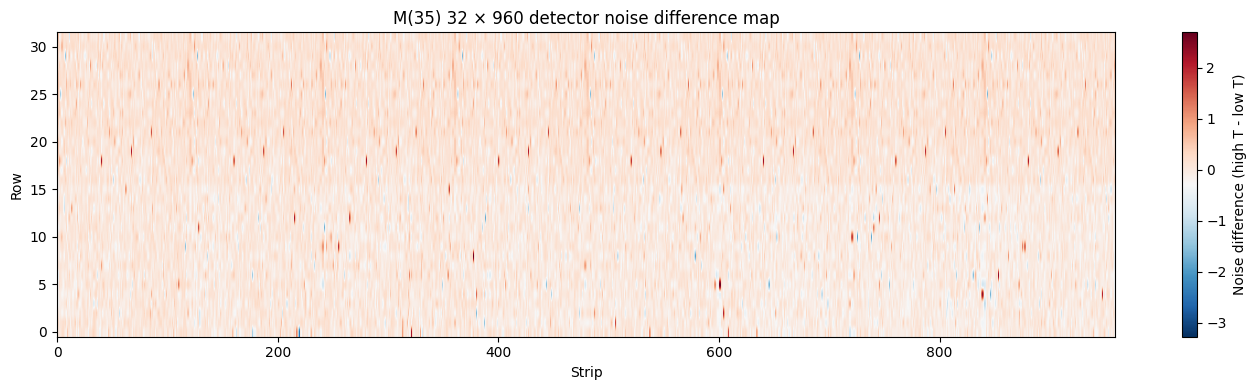

In [14]:
# creates numpy array of zeroes thats same size as data array will be
combinedb = np.zeros([32, 960])
# defines fxn to find diff between 2 histograms counts
def diff_th2(rootpath1, rootpath2, histpath):
    
    values1, _, _ = read_th2(rootpath1, histpath)
    values2, _, _ = read_th2(rootpath2, histpath)

    return values2 - values1
# defines fxn to identify 2d histograms by their hybrid and chip number and return their full file name
def make_histpathb(hybrid, chip):
    return (
        f"Detector/Board_0/OpticalGroup_5/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(5)_H({hybrid})_2DChannelNoise_Chip({chip});1"
    )
# for loop that puts mod35 hybrid 10 data in bottom of np array
for i, chip in enumerate(range(15, 7, -1)):

    histpath = make_histpathb(10, chip)

    diffb = diff_th2(
        "PS_16_FNL-10035_2025-12-01_19h59m48s_-34C_PSquickTest_v6-22.root",
        "PS_16_FNL-10035_2025-12-01_17h45m09s_+21C_PSquickTest_v6-22.root",
        histpath
    )

    diffb = np.fliplr(diffb)

    c0 = i * 120
    c1 = c0 + 120

    combinedb[0:16, c0:c1] = diffb.T
# for loop that puts mod35 hybrid 11 data in top of np array
for i, chip in enumerate(range(8, 16)):

    histpath = make_histpathb(11, chip)

    diffb = diff_th2(
        "PS_16_FNL-10035_2025-12-01_19h59m48s_-34C_PSquickTest_v6-22.root",
        "PS_16_FNL-10035_2025-12-01_17h45m09s_+21C_PSquickTest_v6-22.root",
        histpath
    )

    diffb = np.flipud(diff)

    c0 = i * 120
    c1 = c0 + 120

    combinedb[16:32, c0:c1] = diff.T
# plots 2d histogram showing full noise diff (hot-cold) for all mpa chips
fig, ax = plt.subplots(figsize=(14, 4))

im = ax.imshow(
    combinedb,
    origin="lower",
    aspect="auto",
    cmap="RdBu_r"
)

fig.colorbar(
    im,
    ax=ax,
    label="Noise difference (high T - low T)"
)

ax.set_xlabel("Strip")
ax.set_ylabel("Row")
ax.set_title("M(35) 32 × 960 detector noise difference map")

plt.tight_layout()
plt.savefig("m35_noise_difference_map.png", dpi=150)
plt.savefig("m35_noise_difference_map.pdf")
plt.show()

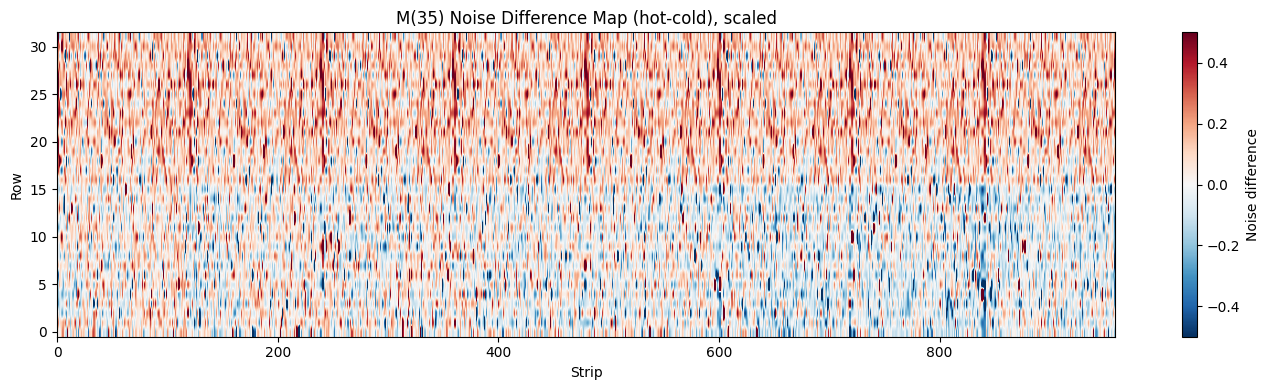

In [38]:
# changes scale
fig, ax = plt.subplots(figsize=(14, 4))

im = ax.imshow(
    combinedb,
    origin="lower",
    aspect="auto",
    cmap="RdBu_r",
    vmin=-0.5,
    vmax=0.5
)

fig.colorbar(im, ax=ax, label="Noise difference")
ax.set_xlabel("Strip")
ax.set_ylabel("Row")
ax.set_title("M(35) Noise Difference Map (hot-cold), scaled")

plt.tight_layout()
plt.savefig("m35_noise_difference_map_scaled.png", dpi=150)
plt.savefig("m35_noise_difference_map_scaled.pdf")
plt.show()

In [14]:
# module 35 (optical group 1), hybrid 2, post-irradiation
countsm3r, binsm3r = read_th1("post_irradiation_for_Emerson/TrackerHistos/TrackerHistos_42.root", "Iteration_1_PSfullTest_2026-03-12_17-23-21/Detector/Board_0/OpticalGroup_1/Hybrid_2/D_B(0)_O(1)_PixelChannelNoise_Hybrid(2);1")

In [15]:
# compare to module 35, hybrid 2 at cold temp which is countsh10c, binsh10c
diffm3r = countsm3r - countsh10c

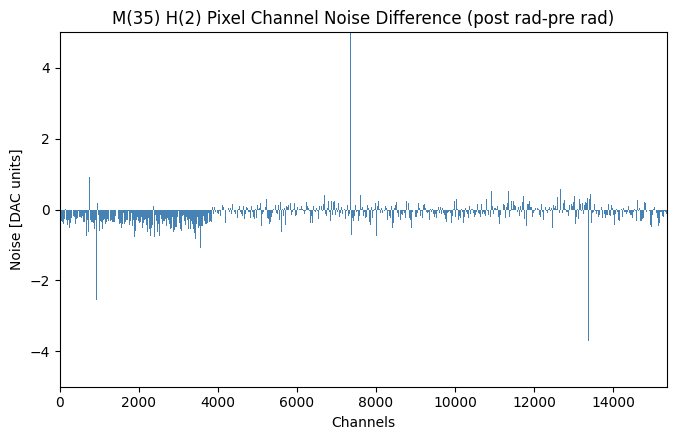

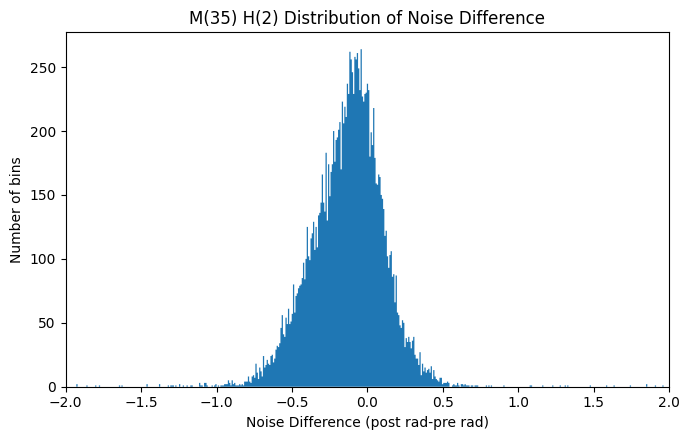

In [16]:
# plots mod35 hybrid 2 noise differences pre and post rad
centers = 0.5 * (binsm3r[:-1] + binsm3r[1:])
widths = np.diff(binsm3r)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(centers, diffm3r, width=widths, align="center",
           color="steelblue", edgecolor="none")
ax.set_xlabel("Channels")
ax.set_ylabel("Noise [DAC units]")
ax.set_title("M(35) H(2) Pixel Channel Noise Difference (post rad-pre rad)")
ax.margins(x=0)
fig.tight_layout()
fig.savefig("m35_rad_noise_diff_hybrid2.png", dpi=150)
fig.savefig("m35_rad_noise_diff_hybrid2.pdf")
ax.set_ylim(-5, 5)
# plots noise difference distribution for mod21 hybrid 2
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(
    diffm3r,
    bins=2000,
    histtype="stepfilled"
)

ax.set_xlabel("Noise Difference (post rad-pre rad)")
ax.set_ylabel("Number of bins")
ax.set_title("M(35) H(2) Distribution of Noise Difference")
ax.set_xlim(-2, 2)

plt.tight_layout()
plt.show()

fig.savefig("m35_rad_noise_diff_h2_distribution.png", dpi=150)
fig.savefig("m35_rad_noise_diff_h2_distribution.pdf")

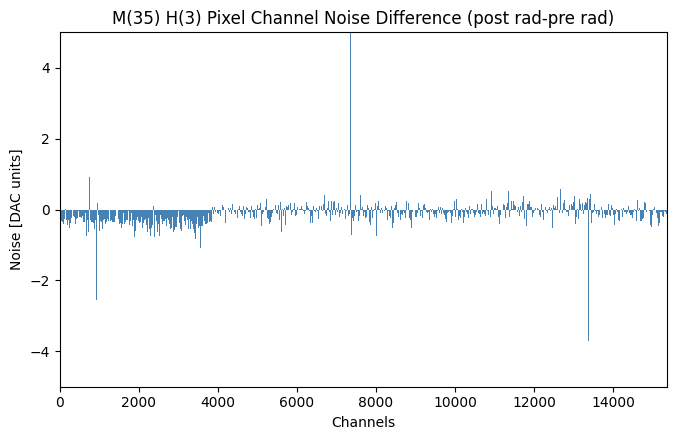

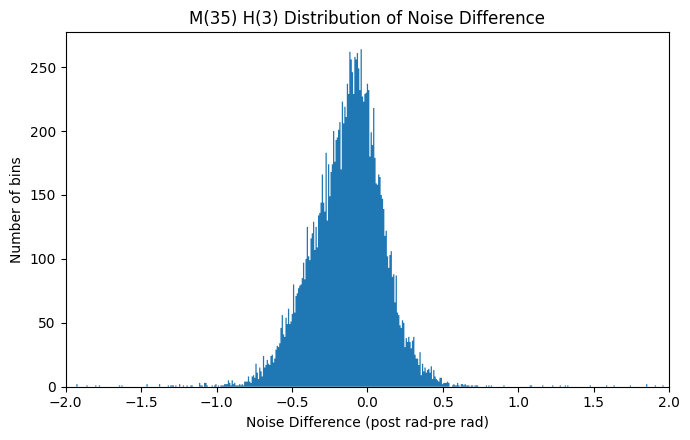

In [17]:
# module 35 (optical group 1), hybrid 3, post-irradiation
countsm3, binsm3 = read_th1("post_irradiation_for_Emerson/TrackerHistos/TrackerHistos_42.root", "Iteration_1_PSfullTest_2026-03-12_17-23-21/Detector/Board_0/OpticalGroup_1/Hybrid_3/D_B(0)_O(1)_PixelChannelNoise_Hybrid(3);1")
# compare to module 35, hybrid 3 at cold temp which is countsh11c, binsh11c
diffm3 = countsm3 - countsh11c
# plots mod35 hybrid 3 noise differences pre and post rad
centers = 0.5 * (binsm3[:-1] + binsm3[1:])
widths = np.diff(binsm3)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(centers, diffm3r, width=widths, align="center",
           color="steelblue", edgecolor="none")
ax.set_xlabel("Channels")
ax.set_ylabel("Noise [DAC units]")
ax.set_title("M(35) H(3) Pixel Channel Noise Difference (post rad-pre rad)")
ax.margins(x=0)
fig.tight_layout()
fig.savefig("m35_rad_noise_diff_hybrid3.png", dpi=150)
fig.savefig("m35_rad_noise_diff_hybrid3.pdf")
ax.set_ylim(-5, 5)
# plots noise difference distribution for mod21 hybrid 2
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(
    diffm3r,
    bins=2000,
    histtype="stepfilled"
)

ax.set_xlabel("Noise Difference (post rad-pre rad)")
ax.set_ylabel("Number of bins")
ax.set_title("M(35) H(3) Distribution of Noise Difference")
ax.set_xlim(-2, 2)

plt.tight_layout()
plt.show()

fig.savefig("m35_rad_noise_diff_h3_distribution.png", dpi=150)
fig.savefig("m35_rad_noise_diff_h3_distribution.pdf")

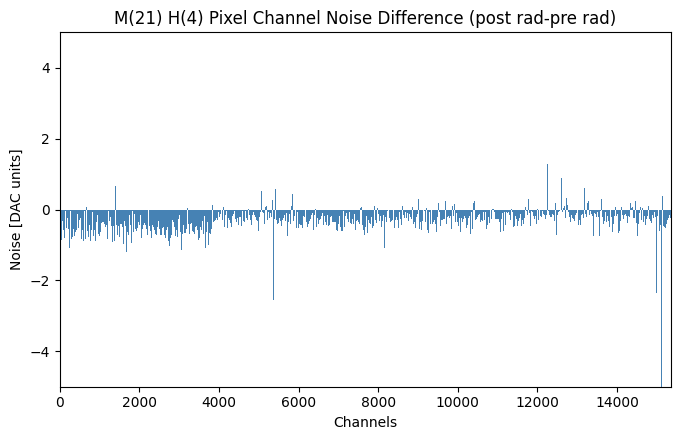

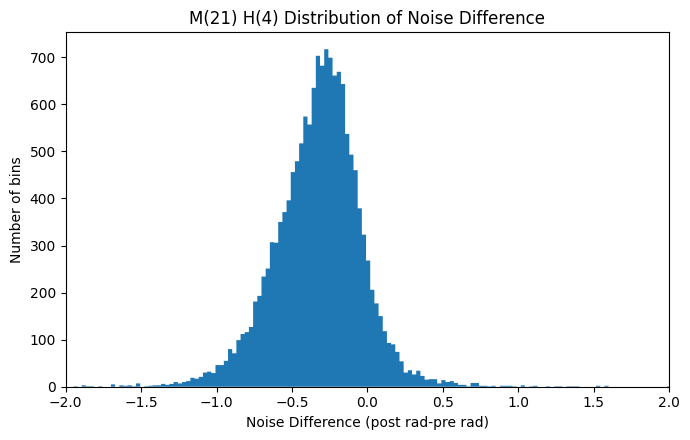

In [18]:
# module 21 (optical group 2), hybrid 4, post-irradiation
countsm2r, binsm2r = read_th1("post_irradiation_for_Emerson/TrackerHistos/TrackerHistos_42.root", "Iteration_1_PSfullTest_2026-03-12_17-23-21/Detector/Board_0/OpticalGroup_2/Hybrid_4/D_B(0)_O(2)_PixelChannelNoise_Hybrid(4);1")
# compare to module 21, hybrid 4 at cold temp which is countsh2r
diffm2r = countsm2r - countsh2r
# plots mod35 hybrid 3 noise differences pre and post rad
centers = 0.5 * (binsm2r[:-1] + binsm2r[1:])
widths = np.diff(binsm2r)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(centers, diffm2r, width=widths, align="center",
           color="steelblue", edgecolor="none")
ax.set_xlabel("Channels")
ax.set_ylabel("Noise [DAC units]")
ax.set_title("M(21) H(4) Pixel Channel Noise Difference (post rad-pre rad)")
ax.margins(x=0)
fig.tight_layout()
fig.savefig("m21_rad_noise_diff_hybrid4.png", dpi=150)
fig.savefig("m21_rad_noise_diff_hybrid4.pdf")
ax.set_ylim(-5, 5)
# plots noise difference distribution for mod21 hybrid 2
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(
    diffm2r,
    bins=2000,
    histtype="stepfilled"
)

ax.set_xlabel("Noise Difference (post rad-pre rad)")
ax.set_ylabel("Number of bins")
ax.set_title("M(21) H(4) Distribution of Noise Difference")
ax.set_xlim(-2, 2)

plt.tight_layout()
plt.show()

fig.savefig("m21_rad_noise_diff_h4_distribution.png", dpi=150)
fig.savefig("m21_rad_noise_diff_h4_distribution.pdf")

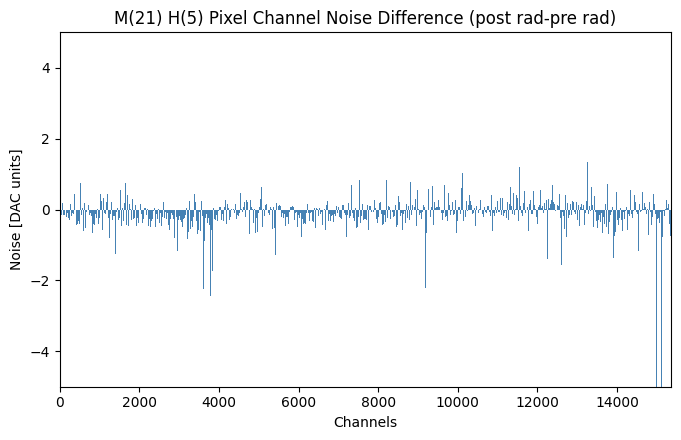

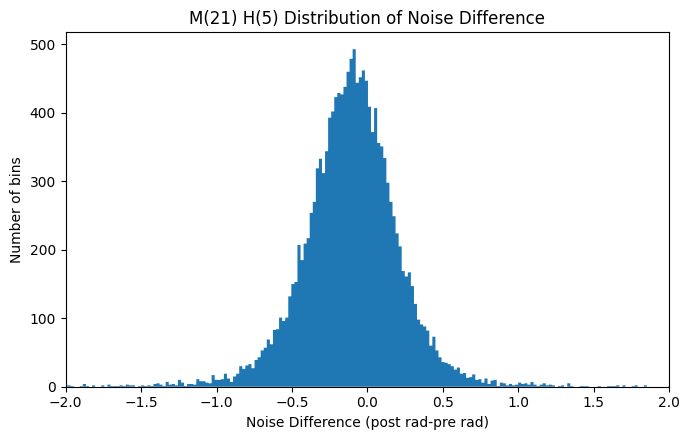

In [19]:
# module 21 (optical group 2), hybrid 5, post-irradiation
countsm2, binsm2 = read_th1("post_irradiation_for_Emerson/TrackerHistos/TrackerHistos_42.root", "Iteration_1_PSfullTest_2026-03-12_17-23-21/Detector/Board_0/OpticalGroup_2/Hybrid_5/D_B(0)_O(2)_PixelChannelNoise_Hybrid(5);1")
# compare to module 21, hybrid 4 at cold temp which is countsh2c
diffm2 = countsm2 - countsh2c
# plots mod35 hybrid 3 noise differences pre and post rad
centers = 0.5 * (binsm2[:-1] + binsm2[1:])
widths = np.diff(binsm2)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(centers, diffm2, width=widths, align="center",
           color="steelblue", edgecolor="none")
ax.set_xlabel("Channels")
ax.set_ylabel("Noise [DAC units]")
ax.set_title("M(21) H(5) Pixel Channel Noise Difference (post rad-pre rad)")
ax.margins(x=0)
fig.tight_layout()
fig.savefig("m21_rad_noise_diff_hybrid5.png", dpi=150)
fig.savefig("m21_rad_noise_diff_hybrid5.pdf")
ax.set_ylim(-5, 5)
# plots noise difference distribution for mod21 hybrid 2
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(
    diffm2,
    bins=2000,
    histtype="stepfilled"
)

ax.set_xlabel("Noise Difference (post rad-pre rad)")
ax.set_ylabel("Number of bins")
ax.set_title("M(21) H(5) Distribution of Noise Difference")
ax.set_xlim(-2, 2)

plt.tight_layout()
plt.show()

fig.savefig("m21_rad_noise_diff_h5_distribution.png", dpi=150)
fig.savefig("m21_rad_noise_diff_h5_distribution.pdf")

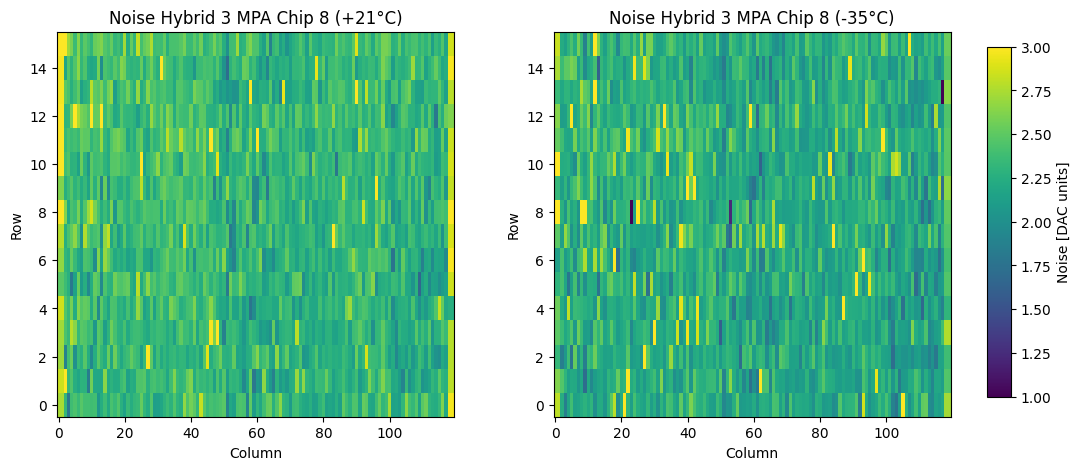

In [20]:
import uproot
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Read a TH2 histogram
# ------------------------------------------------------------
def read_th2(root_file, hist_path):
    with uproot.open(root_file) as f:
        hist = f[hist_path]
        counts, xedges, yedges = hist.to_numpy(flow=False)
    return counts, xedges, yedges


# ------------------------------------------------------------
# Files
# ------------------------------------------------------------
hot_file = "PS_16_FNL-10021_2025-12-01_17h45m09s_+21C_PSquickTest_v6-22.root"
cold_file = "PS_16_FNL-10021_2025-12-01_19h59m48s_-35C_PSquickTest_v6-22.root"

# ------------------------------------------------------------
# Histogram path
# Replace with your actual MPA Chip 8 Module 21 path
# ------------------------------------------------------------
hist_path = (
    "Detector/Board_0/OpticalGroup_1/Hybrid_3/"
    "MPA_8/D_B(0)_O(1)_H(3)_2DChannelNoise_Chip(8);1"
)

# ------------------------------------------------------------
# Read histograms
# ------------------------------------------------------------
hot_counts, xedges, yedges = read_th2(hot_file, hist_path)
cold_counts, _, _ = read_th2(cold_file, hist_path)

# ------------------------------------------------------------
# Fixed color scale
# ------------------------------------------------------------
vmin = 1.0
vmax = 3.0

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Leave room on the right for the colorbar
fig.subplots_adjust(right=0.87, wspace=0.25)

# ---------------- Hot ----------------
im1 = ax1.pcolormesh(
    xedges,
    yedges,
    hot_counts.T,
    shading="auto",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)

ax1.set_title("Noise Hybrid 3 MPA Chip 8 (+21°C)")
ax1.set_xlabel("Column")
ax1.set_ylabel("Row")

# ---------------- Cold ----------------
im2 = ax2.pcolormesh(
    xedges,
    yedges,
    cold_counts.T,
    shading="auto",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)

ax2.set_title("Noise Hybrid 3 MPA Chip 8 (-35°C)")
ax2.set_xlabel("Column")
ax2.set_ylabel("Row")

# ------------------------------------------------------------
# Colorbar in its own axis
# ------------------------------------------------------------
cax = fig.add_axes([0.90, 0.15, 0.02, 0.70])
cbar = fig.colorbar(im1, cax=cax)
cbar.set_label("Noise [DAC units]")

plt.savefig("MPA8_Module21_NoiseComparison.png", dpi=300)
plt.show()

Shape: (1920, 255)


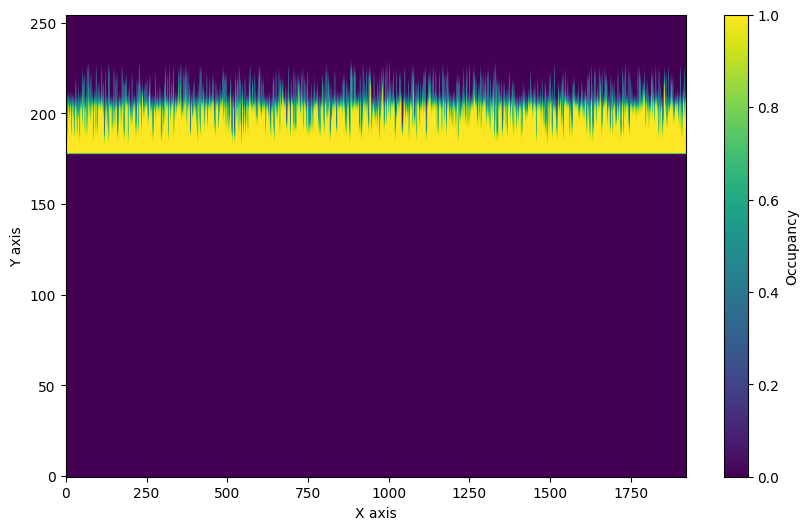

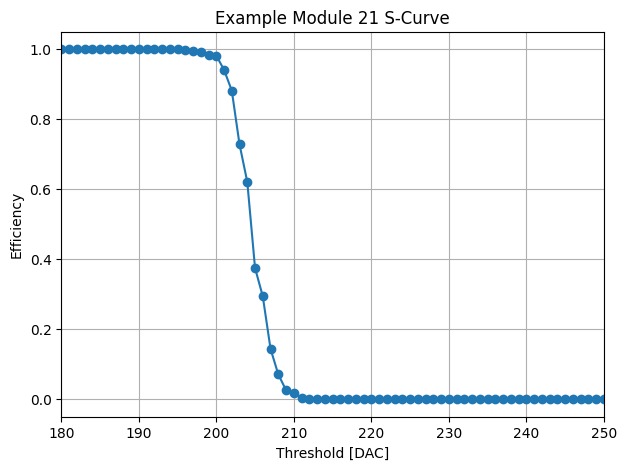

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

root_file = "PS_16_FNL-10021_2025-12-01_17h45m09s_+21C_PSquickTest_v6-22.root"

hist_path = (
    "Detector/Board_0/OpticalGroup_1/Hybrid_3/"
    "MPA_8/D_B(0)_O(1)_H(3)_SCurve_Chip(8);1"
)

with uproot.open(root_file) as f:
    h = f[hist_path]
    counts, xedges, yedges = h.to_numpy(flow=False)

print("Shape:", counts.shape)

# Plot a 2D view first
plt.figure(figsize=(10,6))
plt.imshow(
    counts.T,
    aspect="auto",
    origin="lower",
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]]
)
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.colorbar(label="Occupancy")
plt.show()


# -------------------------------------------------
# Extract one channel S-curve
# -------------------------------------------------

channel = 200

# If channel is the x-axis:
scurve = counts[channel, :]

# Threshold is the y-axis:
threshold = 0.5 * (yedges[:-1] + yedges[1:])


plt.figure(figsize=(7,5))
plt.plot(threshold, scurve, "o-")

plt.xlabel("Threshold [DAC]")
plt.ylabel("Efficiency")
plt.title(f"Example Module 21 S-Curve")

plt.ylim(-0.05,1.05)
plt.xlim(180, 250)
plt.grid()
plt.show()